# Práctica 2 — Análisis Exploratorio de Datos

En este notebook realizarás un **análisis exploratorio de datos (EDA)** sobre un
dataset de 240 estrellas clasificadas en 6 tipos.

**Dataset:** [Stars Dataset — Kaggle](https://www.kaggle.com/datasets/waqi786/stars-dataset)

## Instrucciones generales
- Cada sección tiene celdas marcadas con `# tu código aquí` — ahí debes escribir tu solución.
- Lee las instrucciones en cada celda de markdown **antes** de escribir el código.
- Consulta los enlaces a la documentación oficial para entender los parámetros de cada función.
- Ejecuta el notebook completo **sin errores** antes de hacer commit (`Kernel → Restart & Run All`).

## Contenido
1. [Importar librerías](#1.-Importar-librerías)
2. [Cargar los datos](#2.-Cargar-los-datos)
3. [Exploración inicial](#3.-Exploración-inicial)
4. [Distribución por tipo de estrella](#4.-Distribución-por-tipo-de-estrella)
5. [Temperatura por tipo](#5.-Temperatura-por-tipo-de-estrella)
6. [Luminosidad vs Temperatura](#6.-Luminosidad-vs-Temperatura)
7. [Estadísticas con NumPy](#7.-Estadísticas-con-NumPy)
8. [Diagrama Hertzsprung-Russell](#8.-Diagrama-Hertzsprung-Russell)

---
## Configuración del ambiente

Este proyecto usa **Poetry** para gestionar las dependencias. Antes de abrir el notebook
ejecuta estos comandos **desde la carpeta `practica2_analisis_datos/`**:

```bash
poetry install
poetry run jupyter notebook
```

---
## 1. Importar librerías

Importa las cuatro librerías con sus **alias convencionales**.
Estos alias son estándares en la comunidad — siempre se usan así:

| Librería | Alias | ¿Para qué sirve? | Documentación |
|---|---|---|---|
| `numpy` | `np` | Operaciones matemáticas vectorizadas sobre arrays | [numpy.org/doc/stable](https://numpy.org/doc/stable/user/whatisnumpy.html) |
| `pandas` | `pd` | Análisis y manipulación de datos tabulares (DataFrames) | [pandas.pydata.org/docs](https://pandas.pydata.org/docs/getting_started/index.html) |
| `matplotlib.pyplot` | `plt` | Visualización de datos (gráficas de bajo nivel) | [matplotlib.org/tutorials](https://matplotlib.org/stable/tutorials/index.html) |
| `seaborn` | `sns` | Visualización estadística de alto nivel (sobre matplotlib) | [seaborn.pydata.org/tutorial](https://seaborn.pydata.org/tutorial.html) |

**Sintaxis:** `import librería as alias`

In [5]:
# Importa las cuatro librerías con sus alias convencionales
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
print(f'numpy   {np.__version__}')
print(f'pandas  {pd.__version__}')
print(f'seaborn {sns.__version__}')
print(f'matplotlib {plt.matplotlib.__version__}')

# Una vez que las importes, descomenta estas líneas para verificar las versiones:
# print(f'numpy   {np.__version__}')
# print(f'pandas  {pd.__version__}')
# print(f'seaborn {sns.__version__}')

numpy   2.2.4
pandas  2.2.3
seaborn 0.13.2
matplotlib 3.10.8


---
## 2. Cargar los datos

Usa [`pd.read_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)
para leer el archivo CSV y cargarlo en un **DataFrame** de pandas.

- Revisa la documentación: ¿qué parámetro recibe `read_csv`? ¿qué devuelve?
- El archivo se encuentra en `'../data/star_dataset.csv'` (relativo a la carpeta `notebooks/`)
- Guarda el resultado en una variable llamada `stars`
- Después usa [`.head()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html)
  para mostrar las primeras 5 filas

In [1]:
# Carga el archivo CSV con pd.read_csv() y guárdalo en 'stars'
import pandas as pd

# Si el archivo está en la misma carpeta que este notebook:
stars = pd.read_csv('star_dataset.csv')

# Mostramos las primeras 5 filas para celebrar
stars.head()

# Muestra las primeras 5 filas del DataFrame
# tu código aquí


,Name,Distance (ly),Luminosity (L/Lo),Radius (R/Ro),Temperature (K),Spectral Class
0,Altair,16.594171,9.979192,1.632650,7509.294247,A7V
1,Deneb,2600.490723,196002.627856,202.970526,8503.284796,A2Ia
2,Barnard's Star,6.052616,4.893716,0.222711,3165.959639,M4Ve
3,Polaris,322.601002,2196.241934,37.546813,6048.326915,F7Ib
4,Barnard's Star,5.902392,-1.496486,0.192359,3130.602069,M4Ve


---
## 3. Exploración inicial

Antes de analizar datos siempre hay que entender qué tenemos.

**Celda 3a** — Imprime la información básica del DataFrame:
1. **Dimensiones** con [`.shape`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html)
   — devuelve una tupla `(filas, columnas)`
2. **Nombres de columnas** con [`.columns.tolist()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html)
3. **Tipos de datos** con [`.dtypes`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html)
   — indica si cada columna es `int64`, `float64` o `object` (texto)

**Celda 3b** — Obtén estadísticas descriptivas con
[`.describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html).
Fíjate en la media, desviación estándar, mínimo y máximo de cada columna numérica.

**Celda 3c** — Verifica si hay valores nulos con
[`.isnull()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html)
seguido de `.sum()`. En un dataset limpio todos los valores deben ser 0.

In [2]:
# Imprime: dimensiones, nombres de columnas y tipos de datos
print(f'Dimensiones: {stars.shape}')
print(f'Nombres de columnas: {stars.columns.tolist()}')
print(f'Tipos de datos:\n{stars.dtypes}')


Dimensiones: (1000, 6)
Nombres de columnas: ['Name', 'Distance (ly)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Temperature (K)', 'Spectral Class']
Tipos de datos:
Name                  object
Distance (ly)        float64
Luminosity (L/Lo)    float64
Radius (R/Ro)        float64
Temperature (K)      float64
Spectral Class        object
dtype: object


In [3]:
# Obtén el resumen estadístico de las columnas categóricas
stars.describe(include=['object'])


,Name,Spectral Class
count,1000,1000
unique,29,28
top,Altair,A7V
freq,74,74


In [4]:
# Cuenta los valores nulos por columna
stars.isnull().sum()


Name                 0
Distance (ly)        0
Luminosity (L/Lo)    0
Radius (R/Ro)        0
Temperature (K)      0
Spectral Class       0
dtype: int64

---
## 4. Distribución por tipo de estrella

**Celda 4a** — Usa
[`.value_counts()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html)
sobre la columna `'Spectral Class'` para contar cuántas estrellas hay de cada tipo.
Guarda el resultado en una variable llamada `conteo`.

> Pista: accede a una columna del DataFrame con `df['nombre_columna']`, que devuelve una **Serie**.
> `.value_counts()` es un método de Series.

**Celda 4b** — Crea una **gráfica de barras** de `conteo`:
1. La línea `plt.figure(figsize=(8, 4))` ya está incluida — no la borres
2. Llama [`.plot(kind='bar')`](https://pandas.pydata.org/docs/reference/api/pandas.Series.plot.html)
   sobre `conteo`, usando `color='steelblue'` y `edgecolor='black'`
3. Agrega título con `plt.title(...)`, etiquetas con `plt.xlabel(...)` y `plt.ylabel(...)`
4. Rota las etiquetas del eje X: `plt.xticks(rotation=30, ha='right')`

In [6]:
# Cuenta las estrellas por tipo y guarda el resultado en 'conteo'
# Cuenta las estrellas por tipo y guarda el resultado en 'conteo'
conteo = stars['Spectral Class'].value_counts()

print(conteo)

Spectral Class
A7V         74
A1V         73
A9II        48
B1III       45
M3.5V       45
M2Iab       44
G8III       39
M4Ve        38
K1.5III     38
A0V         38
M7IIIe      37
B2III       37
B0Ia        36
G2V         36
F7Ib        35
B1III-IV    32
A3V         31
F5IV-V      30
B0.5IV      30
B6Vep       29
M2.1V       27
B7V         26
M1.5Iab     26
A2Ia        25
K1V         24
M6V         22
K5III       18
B8Ia        17
Name: count, dtype: int64


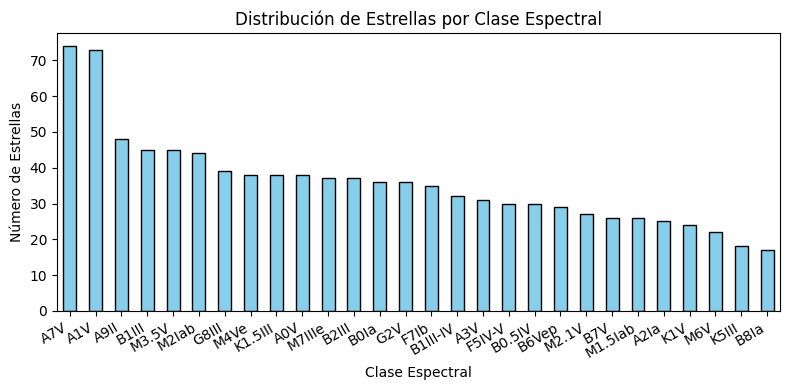

In [9]:
import matplotlib.pyplot as plt

# Tu código de abajo ya debería funcionar:
plt.figure(figsize=(8, 4))
conteo.plot(kind='bar', color='skyblue', edgecolor='black')
# ... resto del código

# Agrega título y etiquetas de ejes
# tu código aquí
plt.title('Distribución de Estrellas por Clase Espectral')
plt.xlabel('Clase Espectral')
plt.ylabel('Número de Estrellas')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 5. Temperatura por tipo de estrella

En esta sección calcularás la temperatura media de dos formas distintas para comparar.

**Celda 5a — Ciclo `for` (enfoque manual):**

Primero filtra el DataFrame para obtener solo las estrellas de tipo `'A7V'`:
```python
filtrado = stars[stars['Spectral Class'] == tipo_objetivo]
```
Luego recorre la columna `'Temperature (K)'` del DataFrame filtrado con un `for`,
acumula la `suma` y el `conteo` (`n`), y calcula la media como `suma / n`.

Consulta [cómo filtrar un DataFrame por valor](https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html)
si necesitas orientación sobre la sintaxis de filtrado.

**Celda 5b — Pandas `.groupby()` (enfoque vectorizado):**

Usa [`.groupby()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)
para calcular la media de **todas las clases a la vez** en una sola línea:
```python
df.groupby('columna_categorica')['columna_numerica'].mean()
```
Ordena de mayor a menor con `.sort_values(ascending=False)`. Guarda en `temp_por_tipo`.
Compara el resultado de `'A7V'` con el valor que obtuviste con el `for`.

**Celda 5c — Boxplot:**

Usa [`sns.boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html) con
`data=stars`, `x='Spectral Class'`, `y='Temperature (K)'`, `order=orden`.

In [13]:
# --- Enfoque 1: ciclo for ---
tipo_objetivo = 'A7V'

# Filtramos los datos
filtrado = stars[stars['Spectral Class'] == tipo_objetivo]

suma = 0
n = 0

# Recorremos la columna de temperatura del dataframe filtrado
for temp in filtrado['Temperature (K)']:
    suma += temp
    n += 1

media_for = suma / n if n > 0 else 0
print(f"Media con ciclo for para {tipo_objetivo}: {media_for}")

# --- Enfoque 2: Pandas .groupby() ---
# Calculamos la media de todas las clases de una vez
temp_por_tipo = stars.groupby('Spectral Class')['Temperature (K)'].mean().sort_values(ascending=False)

print("\nMedia por tipo (ordenada):")
print(temp_por_tipo)

Media con ciclo for para A7V: 7550.178312906775

Media por tipo (ordenada):
Spectral Class
B0.5IV      28001.166630
B0Ia        27502.303666
B1III-IV    25403.170510
B1III       25001.131122
B2III       22600.139741
B6Vep       15003.610593
B7V         12462.119029
B8Ia        12092.293145
A1V         10136.022204
A0V          9607.458129
A3V          8584.693288
A2Ia         8516.840653
A7V          7550.178313
A9II         7349.223744
F5IV-V       6520.419327
F7Ib         6020.393400
G2V          5797.996506
K1V          5261.645715
G8III        4939.733287
K1.5III      4280.090548
K5III        3923.614977
M2Iab        3502.196868
M1.5Iab      3499.130207
M2.1V        3408.914115
M4Ve         3136.076002
M7IIIe       2914.515688
M3.5V        2802.627176
M6V          2795.196060
Name: Temperature (K), dtype: float64


### Comparación: `for` vs. pandas

Con el ciclo `for` calculaste la media de **una sola clase espectral** en varias líneas.
Ahora verás cómo pandas obtiene la media de **todas las clases a la vez** en una sola línea.

Cuando termines la celda 5b, verifica que el resultado de `A7V`
coincida con el valor que obtuviste con el `for`.

In [14]:
# ── Enfoque 2: pandas groupby ─────────────────────────────────────────────────
# Calcula la temperatura promedio por tipo con groupby
# Ordena de mayor a menor y guarda en temp_por_tipo
for temp in filtrado['Temperature (K)']:
    suma += temp
    n += 1
temp_por_tipo = stars.groupby('Spectral Class')['Temperature (K)'].mean().sort_values(ascending=False)


print('Temperatura promedio por clase espectral (K):')
print(temp_por_tipo)
print()
# Imprime una línea de verificación comparando media_manual con el valor de groupby para 'A7V'
# tu código aquí

Temperatura promedio por clase espectral (K):
Spectral Class
B0.5IV      28001.166630
B0Ia        27502.303666
B1III-IV    25403.170510
B1III       25001.131122
B2III       22600.139741
B6Vep       15003.610593
B7V         12462.119029
B8Ia        12092.293145
A1V         10136.022204
A0V          9607.458129
A3V          8584.693288
A2Ia         8516.840653
A7V          7550.178313
A9II         7349.223744
F5IV-V       6520.419327
F7Ib         6020.393400
G2V          5797.996506
K1V          5261.645715
G8III        4939.733287
K1.5III      4280.090548
K5III        3923.614977
M2Iab        3502.196868
M1.5Iab      3499.130207
M2.1V        3408.914115
M4Ve         3136.076002
M7IIIe       2914.515688
M3.5V        2802.627176
M6V          2795.196060
Name: Temperature (K), dtype: float64



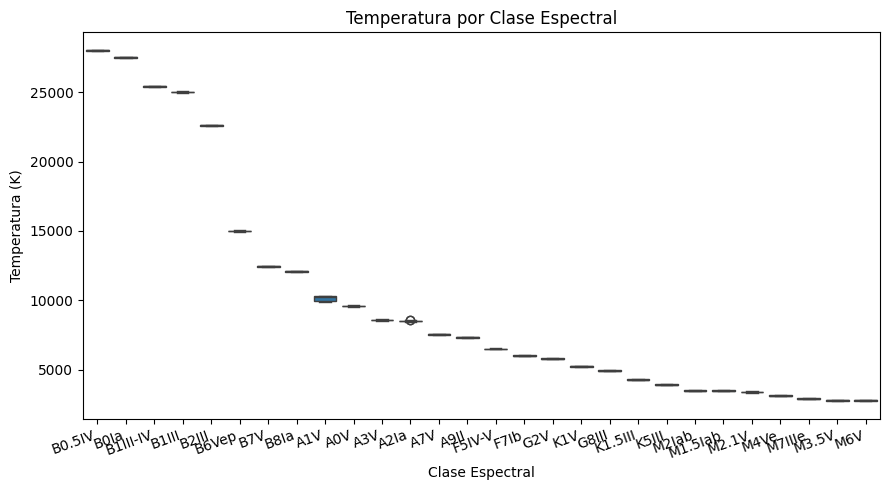

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ahora tu código funcionará:
plt.figure(figsize=(9, 5))
orden = temp_por_tipo.index
sns.boxplot(data=stars, x='Spectral Class', y='Temperature (K)', order=orden)

# ... resto del código ...


# Agrega título y etiquetas de ejes
# tu código aquí
plt.title('Temperatura por Clase Espectral')
plt.xlabel('Clase Espectral')
plt.ylabel('Temperatura (K)')

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

---
## 6. Luminosidad vs Temperatura

La luminosidad varía en muchos órdenes de magnitud (de 0.00008 a 849 420 L/Lo),
por eso necesitamos **escala logarítmica** en el eje Y.

Usa [`sns.scatterplot()`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)
con los siguientes parámetros (revisa la documentación para entender cada uno):
- `data=stars` — el DataFrame
- `x='Temperature (K)'` — temperatura en el eje X
- `y='Luminosity (L/Lo)'` — luminosidad en el eje Y
- `hue='Spectral Class'` — colorea los puntos según la clase espectral
- `style='Spectral Class'` — usa un marcador diferente por clase espectral
- `s=60` — tamaño de los puntos

Después de crear el plot, aplica escala logarítmica al eje Y con
[`plt.yscale('log')`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.yscale.html).

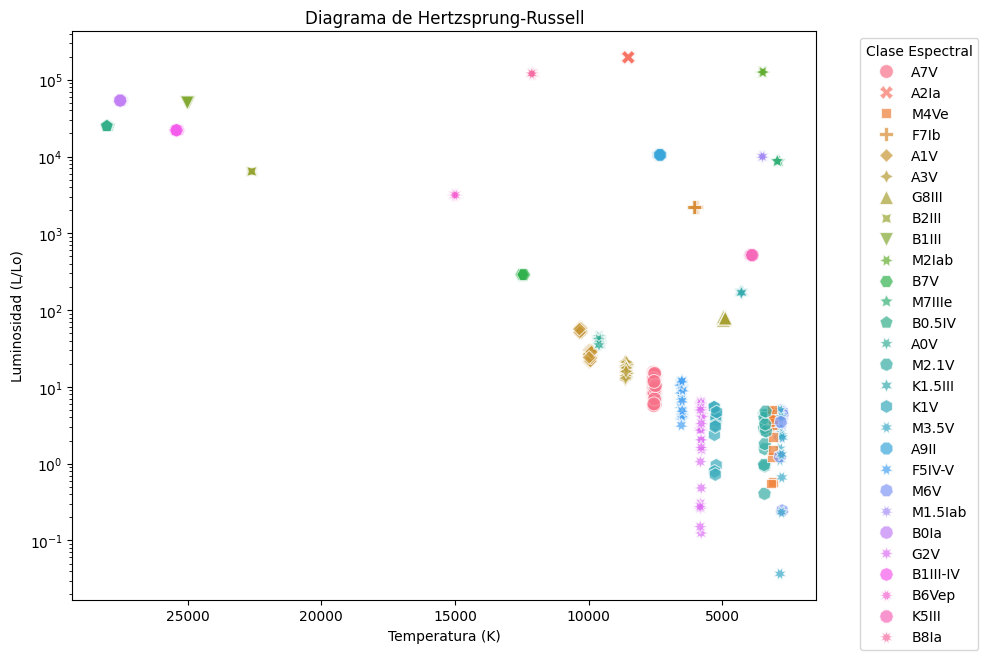

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Crea el scatter plot correctamente
sns.scatterplot(
    data=stars, 
    x='Temperature (K)', 
    y='Luminosity (L/Lo)', 
    hue='Spectral Class',    # Color por clase espectral
    style='Spectral Class',  # Forma por clase espectral
    s=100,                   # Tamaño de los puntos
    alpha=0.7
)

# El Diagrama H-R suele tener el eje X invertido (de mayor a menor temperatura)
plt.gca().invert_xaxis()

# Aplica escala logarítmica al eje Y
plt.yscale('log')

# Etiquetas y título
plt.title('Diagrama de Hertzsprung-Russell')
plt.xlabel('Temperatura (K)')
plt.ylabel('Luminosidad (L/Lo)')

# Mueve la leyenda afuera para que no tape los puntos
plt.legend(title='Clase Espectral', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

---
## 7. Estadísticas con NumPy

NumPy opera sobre **arrays completos** sin ciclos `for`. Por ejemplo,
`np.mean(arr)` calcula la media de todos los elementos de `arr` de una sola vez.

**Celda 7a** — Extrae los arrays con `.values` y calcula estadísticas:
- Extrae: `temperaturas = stars['Temperature (K)'].values`
- Extrae: `radios = stars['Radius (R/Ro)'].values`
- Verifica el tipo con `type(temperaturas)`
- Calcula usando estas funciones de [`numpy.statistics`](https://numpy.org/doc/stable/reference/routines.statistics.html):
  - [`np.mean(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) — media
  - [`np.median(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.median.html) — mediana
  - [`np.std(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.std.html) — desviación estándar
  - [`np.min(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.amin.html) y [`np.max(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.amax.html)

**Celda 7b** — Percentiles y conversión vectorizada:
- Usa [`np.percentile(arr, q)`](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html)
  con `q=[25, 50, 75, 90]` para calcular los 4 percentiles de `radios` de una vez
- Convierte `temperaturas` de Kelvin a Celsius **sin usar ciclo `for`**:
  `celsius = temperaturas - 273.15` (operación vectorizada)

In [24]:
import numpy as np

# Extrae los arrays NumPy con .values
temperaturas = stars['Temperature (K)'].values
radios = stars['Radius (R/Ro)'].values

# Cálculo de estadísticas para temperaturas
print(f"Tipo del array: {type(temperaturas)}")
print(f"Media: {np.mean(temperaturas):.2f}")
print(f"Mediana: {np.median(temperaturas):.2f}")
print(f"Desviación estándar: {np.std(temperaturas):.2f}")
print(f"Mínima: {np.min(temperaturas):.2f}")
print(f"Máxima: {np.max(temperaturas):.2f}")

Tipo del array: <class 'numpy.ndarray'>
Media: 9983.49
Mediana: 7379.01
Desviación estándar: 7903.02
Mínima: 2750.18
Máxima: 28044.28


In [ ]:
import numpy as np
niveles = [25, 50, 75, 90]

# Calcula los percentiles del radio estelar con np.percentile(radios, niveles)
# tu código aquí

p = np.percentile(radios, niveles)

# Imprime cada percentil usando un ciclo for y zip(niveles, p)
for nivel, valor in zip(niveles, p):
    print(f"{nivel} percentil: {valor:.2f}")


# Convierte temperaturas de Kelvin a Celsius de forma vectorizada (sin for)
# celsius = ...
celsius = temperaturas - 273.15


# Imprime las primeras 5 temperaturas en K y en C para comparar
# (usa np.round para redondear a 1 decimal)
print("Temperaturas en K:")
print(np.round(temperaturas[:5], 1))
print("Temperaturas en C:")
print(np.round(celsius[:5], 1))

25 percentil: 1.66
50 percentil: 5.85
75 percentil: 33.72
90 percentil: 369.93
Temperaturas en K:
[7509.3 8503.3 3166.  6048.3 3130.6]
Temperaturas en C:
[7236.1 8230.1 2892.8 5775.2 2857.5]


---
## 8. Diagrama Hertzsprung-Russell

El diagrama H-R es el gráfico más importante en astronomía estelar.
Relaciona temperatura con luminosidad y revela la estructura evolutiva de las estrellas.

Este diagrama tiene **dos particularidades** que debes implementar:
1. **Ambos ejes logarítmicos**: `plt.xscale('log')` y `plt.yscale('log')`
2. **Eje X invertido** (las más calientes a la izquierda): `plt.gca().invert_xaxis()`

**Estructura del código** (el inicio ya está dado, completa las partes marcadas):

```python
tipos   = stars['Spectral Class'].unique()
colores = sns.color_palette('tab10', len(tipos))   # paleta de colores
mapa    = dict(zip(tipos, colores))                # tipo -> color

for tipo, grupo in stars.groupby('Spectral Class'):
    plt.scatter(grupo['Temperature (K)'],
                grupo['Luminosity (L/Lo)'],
                label=tipo, color=mapa[tipo], s=40, alpha=0.8)
```

Parámetros de [`plt.scatter()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)
que debes entender: `x`, `y`, `label`, `color`, `s` (tamaño), `alpha` (transparencia).

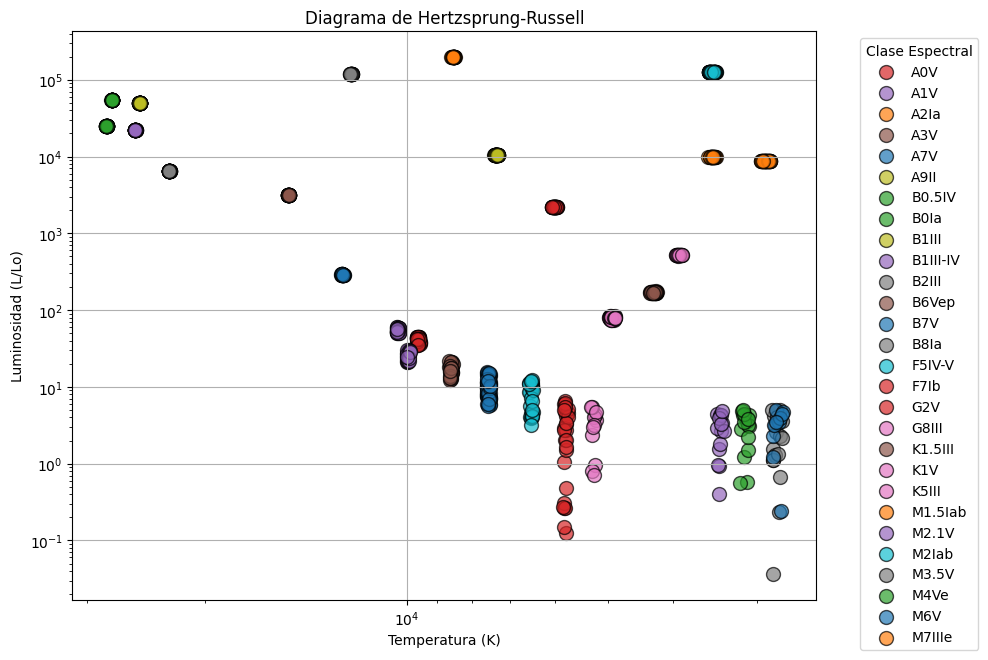

In [26]:
tipos   = stars['Spectral Class'].unique()
colores = sns.color_palette('tab10', len(tipos))
mapa    = dict(zip(tipos, colores))

plt.figure(figsize=(10, 7))

# Itera con stars.groupby('Spectral Class') y crea un plt.scatter() por cada tipo
for tipo, grupo in stars.groupby('Spectral Class'):
    plt.scatter(
        grupo['Temperature (K)'], 
        grupo['Luminosity (L/Lo)'], 
        label=tipo, 
        color=mapa[tipo], 
        alpha=0.7, 
        edgecolor='black', 
        s=100
    )


# Aplica escala logarítmica en ambos ejes (xscale y yscale)

plt.xscale('log')
plt.yscale('log')


# Invierte el eje X con plt.gca().invert_xaxis()

plt.gca().invert_xaxis()


# Agrega: título, etiquetas de ejes, leyenda y grid

plt.title('Diagrama de Hertzsprung-Russell')
plt.xlabel('Temperatura (K)')
plt.ylabel('Luminosidad (L/Lo)')
plt.legend(title='Clase Espectral', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()